# Image Score Redistribution (Chains Strategy)
This notebook rebalances image scores using chains derived from comparison history.
Each chain maps its best -> worst item to scores 1.0 -> 0.0. Chains are applied from shorter to longer, so long chains will overwrite earlier short-chain assignments.

Options: toggle `UPDATE_DATABASE`, `MOVE_FILES`, `DRY_RUN`.

In [ ]:
import os
import sys
from pathlib import Path

# The notebook is in external_modules/step01ranking_new/
# We need to add the plugin root (comfyui-image-scorer/) to sys.path to find 'shared'
notebook_path = Path(os.getcwd()).resolve()
plugin_root = notebook_path.parents[1]
print(f"Plugin root: {plugin_root}")

if str(plugin_root) not in sys.path:
    sys.path.insert(0, str(plugin_root))

# Also ensure the current folder is in path for relative imports
if str(notebook_path) not in sys.path:
    sys.path.insert(0, str(notebook_path))

print(f"Current working directory: {os.getcwd()}")


Plugin root: E:\ComfyUI\custom_nodes\comfyui-image-scorer
Current working directory: e:\ComfyUI\custom_nodes\comfyui-image-scorer\external_modules\step01ranking_new


In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

# Import local modules
from shared.graph.crystal_graph import crystal_graph, NodeProxy, ChainProxy
from database.images_table import get_all_images, update_image_score_confidence
from database.comparisons_table import get_all_comparisons
from file_management.path_handler import (
    get_ranked_root,
    compute_path_from_filename,
    find_image_path,
    sync_image_metadata_to_json,
)
from image_processor import ImageProcessor


In [ ]:
# --- CONFIGURATION ---
UPDATE_DATABASE = True  # Set to True to save new scores to DB
MOVE_FILES = False  # Set to True to move files to new folders
DRY_RUN = False  # If True, no changes are actually made
PLOT_BINS = 100  # Number of bins for the histogram
# Safety limits for chain enumeration (tune if dataset is large)
MAX_CHAIN_DEPTH = 50000
MAX_CHAINS = 20000000
# ---------------------


Fetching images from database...


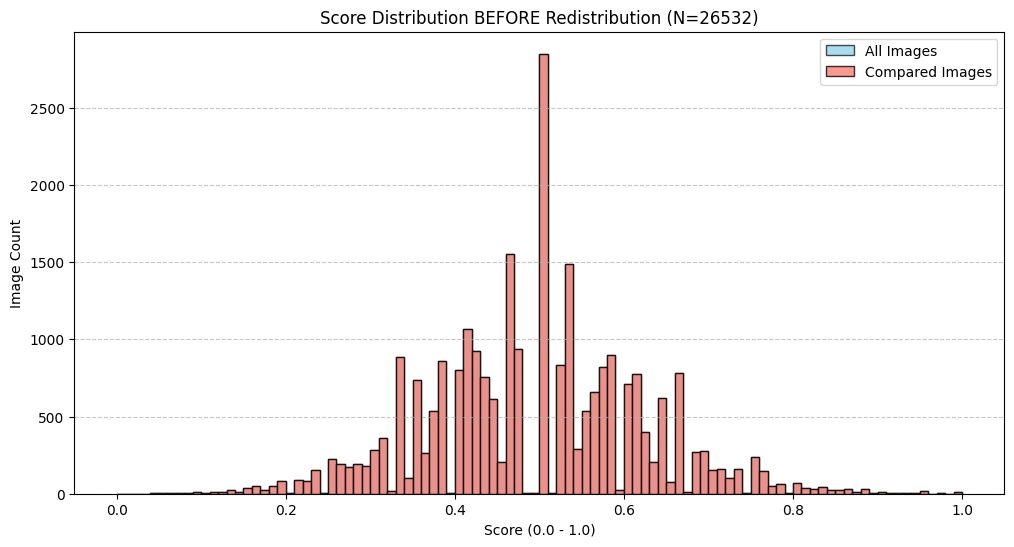

In [ ]:
print("Fetching images from database...")

all_images = get_all_images()
compared_images = [img for img in all_images if img.get("comparison_count", 0) > 0]
if not all_images:
    print("No images found!")
else:
    before_scores = [img.get("score", 0.0) for img in all_images]
    compared_scores = [img.get("score", 0.0) for img in compared_images]
    plt.figure(figsize=(12, 6))
    plt.hist(
        before_scores,
        bins=PLOT_BINS,
        color="skyblue",
        edgecolor="black",
        alpha=0.7,
        label="All Images",
    )
    plt.hist(
        compared_scores,
        bins=PLOT_BINS,
        color="salmon",
        edgecolor="black",
        alpha=0.8,
        label="Compared Images",
    )
    plt.title(f"Score Distribution BEFORE Redistribution (N={len(all_images)})")
    plt.xlabel("Score (0.0 - 1.0)")
    plt.ylabel("Image Count")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.legend()
    plt.show()


In [ ]:
# Build chain graph from comparison history using CrystalGraph
from collections import Counter

print("Fetching comparisons from database (direct comparisons only, weight==1.0)...")
all_comps = [c for c in get_all_comparisons() if float(c.get("weight", 1.0)) == 1.0]

# crystal_graph.rebuild_from_database(images=all_images, comparisons=all_comps)

stats = crystal_graph.get_graph_stats()
print(
    f"Nodes in comparison graph: {stats['total_images']} | edges (approx): {len(crystal_graph.get_all_links())}"
)


Fetching comparisons from database (direct comparisons only, weight==1.0)...
Nodes in comparison graph: 26532 | edges (approx): 38682


In [ ]:
# get all nodes


all_nodes: list[NodeProxy] = crystal_graph.get_all_nodes()

# This allows us to determine the "main chain" for each node
main_chain_map: dict[int, list[str]] = {}
with tqdm(
    total=len(all_nodes), desc="Building main chain mapping", unit="node"
) as pbar:
    for node in all_nodes:
        chain_id: int = node.get_chain()[0].id
        if chain_id not in main_chain_map:
            main_chain_map[chain_id] = []
        main_chain_map[chain_id].append(node.filename)
        pbar.update(1)

print(
    f"Built main chain mapping for {len(main_chain_map)} unique chains and {len(all_nodes)} images."
)


Building main chain mapping:   0%|          | 0/26532 [00:00<?, ?node/s]

Built main chain mapping for 9841 unique chains and 26532 images.


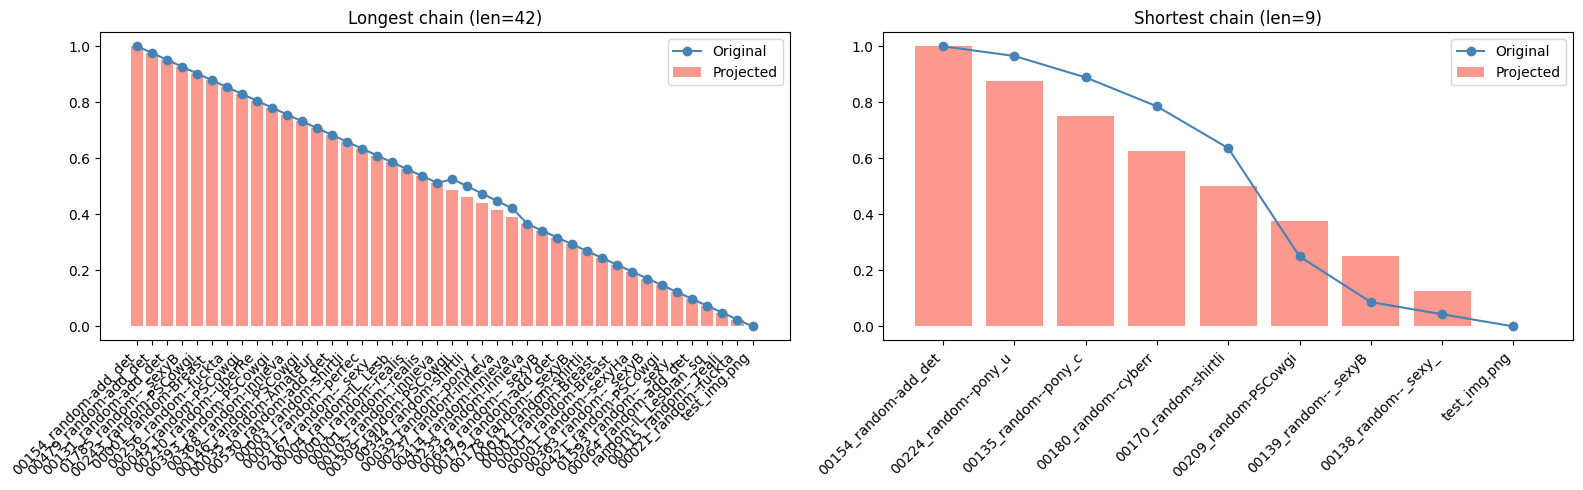

Longest chain (filename, projected, original):
00154_random-add_detail-cyberrealistic_v90.png....,  projected=1.000  original=1.000
00479_random-add_detail-SD15_uberRealisticPornMerge_v23Final.png....,  projected=0.976  original=0.976
00131_random-add_detail-SD15_dreamshaper_8.png....,  projected=0.951  original=0.951
01785_random--_sexyBabes_v10.png....,  projected=0.927  original=0.927
00243_random-PSCowgirl-lazymixRealAmateur_v40.png....,  projected=0.902  original=0.902
00001_random-Breast Helper - [Concept] - Version 1-realisticVisionV60B1_v51HyperVAE.png....,  projected=0.878  original=0.878
00256_random--fucktasticRealCheckpointPony_52.png....,  projected=0.854  original=0.854
00049_random-PSCowgirl-cyberrealistic_v90.png....,  projected=0.829  original=0.829
00210_random--uberRealisticPornMergePonyxl_ponyxlHybridV1.png....,  projected=0.805  original=0.805
00393_random-PSCowgirl-SD15_cyberrealistic_v90.png....,  projected=0.780  original=0.780
00368_random-innievag-SD15_cyberre

In [ ]:
# Show shortest and longest chains with projected and original scores
from typing import Any

valid_chains = crystal_graph.get_all_chains()
# valid_chains = [ch for ch in chains if len(ch.nodes) >= 2]
if not valid_chains:
    print("No chains found.")
    sys.exit(0)

lengths = [ch.length for ch in valid_chains]
min_len = min(lengths)
max_len = max(lengths)
shortest_chain = next(ch for ch in valid_chains if ch.length == min_len)
# pick one of the longest chains (reverse for likely longer recent chains)
longest_chain = next(ch for ch in reversed(valid_chains) if ch.length == max_len)

original_scores_map: dict[str, float] = {
    img["filename"]: float(img["score"]) for img in all_images
}


def chain_table(chain_obj):
    L = len(chain_obj.nodes)
    projected = [1.0 - (i / (L - 1)) for i in range(L)]
    original = [original_scores_map.get(n.filename, 0.0) for n in chain_obj.nodes]
    lines = []
    for node, proj, orig in zip(chain_obj.nodes, projected, original):
        lines.append(
            f"{node.filename:20}....,  projected={proj:0.3f}  original={orig:0.3f}"
        )
    return lines, projected, original


import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# Longest
lines_long, proj_long, orig_long = chain_table(longest_chain)
x_long = range(len(longest_chain.nodes))
axes[0].bar(x_long, proj_long, color="salmon", alpha=0.8, label="Projected")
axes[0].plot(x_long, orig_long, marker="o", color="steelblue", label="Original")
axes[0].set_xticks(x_long)
axes[0].set_xticklabels(
    [n.filename[:20] for n in longest_chain.nodes],
    rotation=45,
    ha="right",
)
axes[0].set_ylim(-0.05, 1.05)
axes[0].set_title(f"Longest chain (len={len(longest_chain.nodes)})")
axes[0].legend()

# Shortest
lines_short, proj_short, orig_short = chain_table(shortest_chain)
x_short = range(len(shortest_chain.nodes))
axes[1].bar(x_short, proj_short, color="salmon", alpha=0.8, label="Projected")
axes[1].plot(x_short, orig_short, marker="o", color="steelblue", label="Original")
axes[1].set_xticks(x_short)
axes[1].set_xticklabels(
    [n.filename[:20] for n in shortest_chain.nodes],
    rotation=45,
    ha="right",
)
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_title(f"Shortest chain (len={len(shortest_chain.nodes)})")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Longest chain (filename, projected, original):")
for l in lines_long:
    print(l)
print("\nShortest chain (filename, projected, original):")
for l in lines_short:
    print(l)


Applying chains (longest first, main chain check):   0%|          | 0/9842 [00:00<?, ?it/s]

Chain ID 854 not found in main_chain_map, skipping.
Applied 9841 chains
Assigned scores to 26532 node instances from main chains
Unique images assigned: 26532
Unassigned images: 0
errors (chain IDs not in main_chain_map)1: [854]


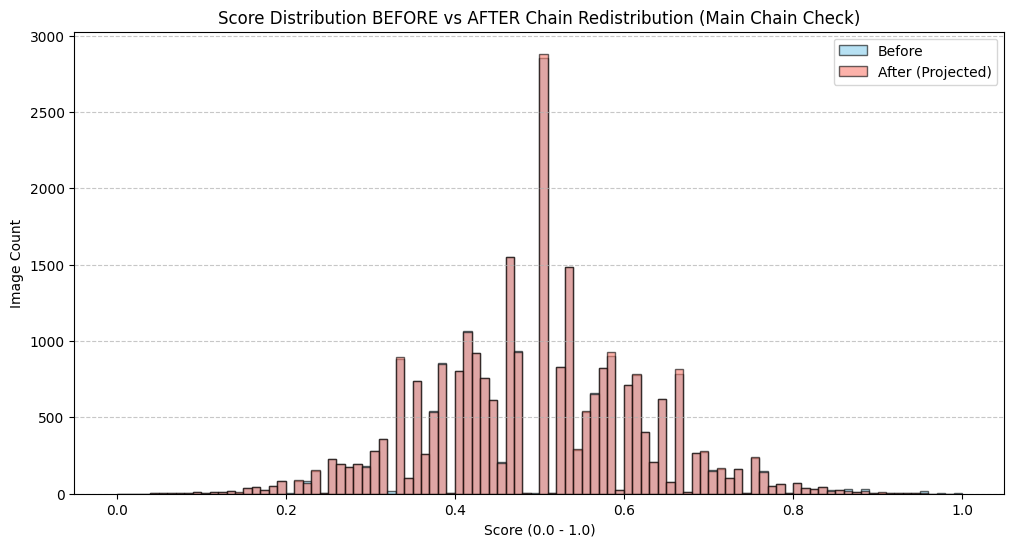

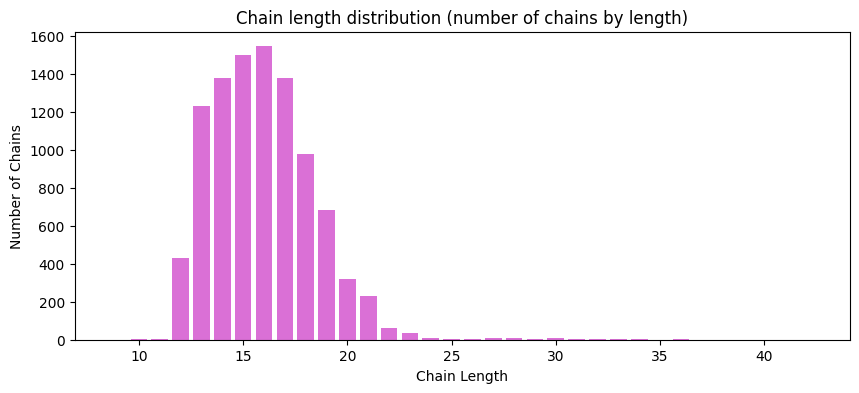

Top 10 longest chain lengths used: [42, 40, 39, 38, 37, 36, 35, 34, 33, 32]


In [ ]:
# Strategy: Apply chains from LONGEST to SHORTEST (descending order)
# Only update a score if the current chain is the main chain for that node
# This preserves the primary ranking path for each node

# Sort chains by length descending (longest first)


chains_sorted: list[ChainProxy] = sorted(
    valid_chains, key=lambda ch: ch.length, reverse=True
)

# Get original scores
scores_by_filename: dict[str, float] = original_scores_map

# Track which images have been assigned scores
assigned: set[str] = set()

# Apply chains sequentially - longest first, only if it's the main chain for that node
chains_applied_count = 0
scores_updated_count = 0
errors: list[int] = []
for chain in tqdm(
    chains_sorted, desc="Applying chains (longest first, main chain check)"
):
    length: int = chain.length
    if length <= 1:
        continue
    chain_id: int = chain.id
    if chain_id not in main_chain_map:
        print(f"Chain ID {chain_id} not found in main_chain_map, skipping.")
        errors.append(chain_id)
        continue
    main_nodes: list[str] = main_chain_map[chain_id]

    chains_applied_count += 1
    for idx, node in enumerate(chain.nodes):
        filename: str = node.filename

        if filename not in main_nodes or filename in assigned:
            continue

        # Only assign if not already assigned
        projected_score: float = 1.0 - (idx / (length - 1))
        scores_by_filename[filename] = float(projected_score)
        assigned.add(filename)
        scores_updated_count += 1

print(f"Applied {chains_applied_count} chains")
print(f"Assigned scores to {scores_updated_count} node instances from main chains")
print(f"Unique images assigned: {len(assigned)}")
print(f"Unassigned images: {len(all_images) - len(assigned)}")
print(f"errors (chain IDs not in main_chain_map){len(errors)}: {errors}")
# Prepare updates list to match existing notebook format (use score key)
updates: list[dict[str, Any]] = []
for img in all_images:
    filename = img["filename"]
    old_score = float(img["score"])
    score = float(scores_by_filename[filename])
    updates.append(
        {
            "filename": filename,
            "old_score": old_score,
            "score": score,
            "confidence": float(img["confidence"]),
            "count": int(img["comparison_count"]),
        }
    )

# Plot projected distribution after chains applied (overlay BEFORE/AFTER)
after_scores = [up["score"] for up in updates]
plt.figure(figsize=(12, 6))
plt.hist(
    before_scores,
    bins=PLOT_BINS,
    color="skyblue",
    edgecolor="black",
    alpha=0.6,
    label="Before",
)
plt.hist(
    after_scores,
    bins=PLOT_BINS,
    color="salmon",
    edgecolor="black",
    alpha=0.6,
    label="After (Projected)",
)
plt.title("Score Distribution BEFORE vs AFTER Chain Redistribution (Main Chain Check)")
plt.xlabel("Score (0.0 - 1.0)")
plt.ylabel("Image Count")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend()
plt.show()

# Chain length distribution
chain_lengths: Counter[int] = Counter(chain.length for chain in valid_chains)
if chain_lengths:
    lengths, counts = zip(*sorted(chain_lengths.items()))
    plt.figure(figsize=(10, 4))
    plt.bar(lengths, counts, color="orchid")
    plt.title("Chain length distribution (number of chains by length)")
    plt.xlabel("Chain Length")
    plt.ylabel("Number of Chains")
    plt.show()

# Diagnostics - show chain length distribution after new strategy
chain_lengths_applied = Counter()
for chain in chains_sorted:
    if len(chain.nodes) >= 2:
        chain_lengths_applied[len(chain.nodes)] += 1

top_chain_lengths = sorted(chain_lengths_applied.keys(), reverse=True)[:10]
print("Top 10 longest chain lengths used:", top_chain_lengths)


In [ ]:
# Commit updates to DB and optionally move files based on new scores
if UPDATE_DATABASE:
    if DRY_RUN:
        print(f"[DRY RUN] Would update database scores for {len(updates)} images.")
    else:
        print(f"Updating database for {len(updates)} images...")
        for up in tqdm(updates, desc="Updating DB"):
            update_image_score_confidence(
                up["filename"], up["score"], up["confidence"], up["count"]
            )
else:
    print("Database update skipped (UPDATE_DATABASE = False).")

if MOVE_FILES:
    moved = 0
    errors = 0

    for up in tqdm(updates, desc="Relocating files"):
        filename = up["filename"]
        current = find_image_path(filename)
        if not current:
            continue

        # Compute target based on the score
        target = compute_path_from_filename(filename, up["score"])

        if current != target:
            if DRY_RUN:
                moved += 1
            else:
                try:
                    ok = sync_image_metadata_to_json(
                        filename, up["score"], up["confidence"], up["count"]
                    )
                    if ok:
                        moved += 1
                    else:
                        errors += 1
                except Exception:
                    errors += 1

    verb = "Would move" if DRY_RUN else "Moved"
    print(f"{verb} {moved} files. Errors: {errors}")
else:
    print("File movement skipped (MOVE_FILES = False).")

print("Done.")


Updating database for 26532 images...


Updating DB:   0%|          | 0/26532 [00:00<?, ?it/s]

File movement skipped (MOVE_FILES = False).
Done.
